# Extract paths

In [1]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pandas as pd
import os
import glob

TRAIN_DATA_PATH = '/kaggle/input/brisc2025/brisc2025/segmentation_task/train'
TEST_DATA_PATH = '/kaggle/input/brisc2025/brisc2025/segmentation_task/test'
# train_images = glob.glob(TRAIN_DATA_PATH + '/images/*.jpg')
# train_masks = glob.glob(TRAIN_DATA_PATH + '/masks/*.png')

In [2]:
arr = {'image_path' : [], 'mask_path': []}
for dirname, _, filenames in os.walk(TRAIN_DATA_PATH + '/images'):
    for filename in filenames:
        arr['image_path'].append(dirname + '/' + filename)
        arr['mask_path'].append(TRAIN_DATA_PATH + '/masks/' + filename.split('.jpg')[0] + '.png')

df_train = pd.DataFrame(arr)
display(df_train.shape)

arr = {'image_path' : [], 'mask_path': []}
for dirname, _, filenames in os.walk(TEST_DATA_PATH + '/images'):
    for filename in filenames:
        arr['image_path'].append(dirname + '/' + filename)
        arr['mask_path'].append(TEST_DATA_PATH + '/masks/' + filename.split('.jpg')[0] + '.png')

df_test = pd.DataFrame(arr)
display(df_test.shape)

(3933, 2)

(860, 2)

# Visualization

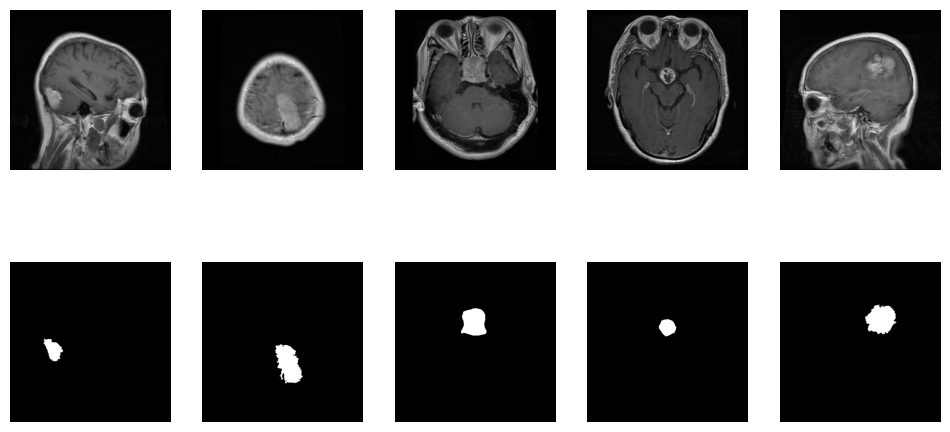

In [3]:
def show_images():
    num_images = 5
    selected_images = df_train.sample(n=num_images)
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    for i in range(num_images):
        image = Image.open(selected_images.iloc[i]['image_path'])
        # if len(np.array(image).shape)==3:
        #     image = np.array(image)
        #     new_channel_data = np.full_like(image[:, :, 0], fill_value=255)
        #     image[:, : , 0] = new_channel_data
        # print('Image shape:', np.array(image).shape)
        axes[0, i % num_images].imshow(image, cmap='gray')
        axes[0, i % num_images].axis('off')

        
        mask = Image.open(selected_images.iloc[i]['mask_path'])
        # print('Mask shape:', np.array(mask).shape)
        axes[1, i % num_images].imshow(mask, cmap='gray')
        axes[1, i % num_images].axis('off')
        # print('**********************')
    
    plt.show()

show_images()

In [4]:
import pandas as pd

shape_analyze = {'shapes' : []}
for image in df_train.iterrows():
    current_img = Image.open(image[1]['image_path'])
    current_img = np.array(current_img)
    shape_analyze['shapes'].append(current_img.shape)

shape_analyze = pd.DataFrame(shape_analyze)
shape_analyze

,shapes
0,"(512, 512)"
1,"(512, 512)"
2,"(512, 512)"
3,"(512, 512)"
4,"(512, 512)"
...,...
3928,"(512, 512, 3)"
3929,"(512, 512)"
3930,"(512, 512)"
3931,"(512, 512)"


In [5]:
shape_analyze.value_counts()

shapes       
(512, 512)       2272
(512, 512, 3)    1494
(256, 256, 3)      13
(256, 256)         12
(225, 225, 3)       8
                 ... 
(252, 200, 3)       1
(251, 205, 3)       1
(249, 206, 3)       1
(249, 204, 3)       1
(320, 257, 3)       1
Name: count, Length: 126, dtype: int64

In [6]:
shape_analyze['channel'] = shape_analyze['shapes'].apply(lambda x : x[2] if len(x) == 3 else 0)
shape_analyze['channel'].value_counts()

channel
0    2284
3    1649
Name: count, dtype: int64

In [7]:
selected_image = df_train.sample()
img = Image.open(selected_image.iloc[0]['image_path'])
img_arr = np.array(img)
np.unique(img_arr, return_counts=True)

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
         26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
         39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
         52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
         65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
         78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
         91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
        104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
        117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
        130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
        143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
        156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
        169, 170, 171, 172, 173, 174, 175, 176, 177

In [8]:
mask_img = np.array(Image.open(selected_image.iloc[0]['mask_path']))

In [9]:
mask_pixels = np.where(mask_img != 0)
zero_pixels = np.where(mask_img == 0)
mask_pixels

(array([176, 176, 176, ..., 223, 223, 223]),
 array([224, 226, 230, ..., 263, 264, 270]))

In [10]:
lower_bound = np.min(img_arr[mask_pixels])
upper_bound = np.max(img_arr[mask_pixels])
lower_bound, upper_bound = max(0, lower_bound*0.9), min(upper_bound*1.1,  255)

(Text(0.5, 1.0, 'Mask'), ([], []), ([], []))

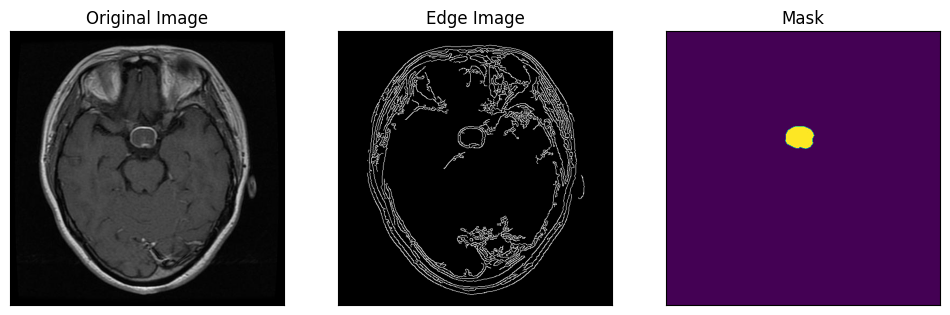

In [11]:
import cv2 as cv

img = cv.imread(selected_image.iloc[0]['image_path'], cv.IMREAD_GRAYSCALE)
edges = cv.Canny(img, lower_bound, upper_bound)

plt.figure(figsize=(12,6))
plt.subplot(131),plt.imshow(img,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(edges,cmap = 'gray')
plt.title('Edge Image'), plt.xticks([]), plt.yticks([])
plt.subplot(133), plt.imshow(Image.open(selected_image.iloc[0]['mask_path']))
plt.title('Mask'), plt.xticks([]), plt.yticks([])

In [12]:
np.unique(mask_img[mask_pixels],return_counts=True)

(array([  1,   2,   3,   4,   5, 250, 251, 252, 253, 254, 255], dtype=uint8),
 array([ 122,   88,   40,   20,    6,    5,   13,   25,   62,  109, 1592]))

In [13]:
mask_img.shape

(512, 512)

# Train validation split

In [14]:
from sklearn.model_selection import train_test_split

df_train, df_val = train_test_split(df_train, test_size=0.2, random_state=36, shuffle=False) # shuffle when load
df_train.to_csv('train.csv')
df_val.to_csv('val.csv')
df_test.to_csv('test.csv')

# Find threshold for mask

In [15]:
def threshold_finding(df = df_train):
    freq = np.zeros(256, dtype=np.int64)
    for path in df_train.iterrows():
        mask_path = path[1]['mask_path']
        mask_arr = np.array(Image.open(mask_path))
        # print(mask_arr.flatten())
        bin_count = np.bincount(mask_arr.flatten())
        freq+=bin_count
    # Apply threshold for tumor region
    for i in range(255,-1,-1):
        if freq[i] == 0:
            return i
    return 225 # Default value

threshold_mask = threshold_finding(df_train)
print(threshold_finding())


245


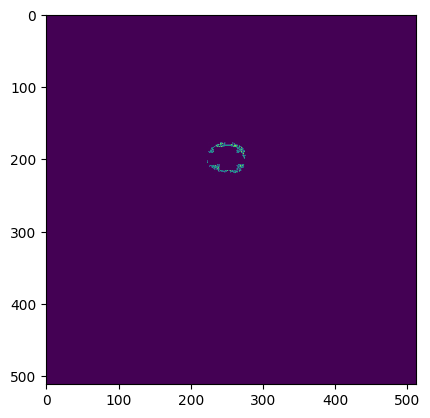

In [16]:
mask_img[np.where(mask_img==255)] = 0
plt.imshow(mask_img)

In [17]:
shape_analyze = {'shapes' : []}
for image in df_train.iterrows():
    current_img = Image.open(image[1]['mask_path'])
    current_img = np.array(current_img)
    shape_analyze['shapes'].append(current_img.shape)

shape_analyze = pd.DataFrame(shape_analyze)
shape_analyze.value_counts()

shapes    
(512, 512)    3010
(256, 256)      24
(225, 225)       8
(442, 442)       3
(251, 201)       2
              ... 
(270, 250)       1
(264, 420)       1
(261, 232)       1
(252, 200)       1
(325, 254)       1
Name: count, Length: 98, dtype: int64

In [18]:
shape_analyze['channel'] = shape_analyze['shapes'].apply(lambda x : x[2] if len(x) == 3 else 0)
shape_analyze['channel'].value_counts()

channel
0    3146
Name: count, dtype: int64

# Preprocessing

In [19]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T

In [20]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
class SWIN_HAF_dataset(Dataset):
    def __init__(self, df, threshold=225, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform # Augmentation defines later
        self.threshold = threshold
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image = cv.imread(self.df.iloc[idx]['image_path'], cv.COLOR_BGR2RGB)
        mask = cv.imread(self.df.iloc[idx]['mask_path'], cv.IMREAD_GRAYSCALE)

        mask = np.where(mask>self.threshold, 1, 0)
        mask = mask.astype(np.uint8)
        
        
        image = cv.resize(image, (512,512), interpolation=cv.INTER_LINEAR)
        mask = cv.resize(mask, (512, 512), interpolation=cv.INTER_NEAREST)

        if len(image.shape) ==2:
            image = np.dstack([image,image,image])
        image = image / 255.0
        if self.transform:
            image = self.transform(image)
    
        return torch.tensor(image, device=DEVICE), torch.tensor(mask, device=DEVICE).unsqueeze(0)

In [21]:
swin_ds_train = SWIN_HAF_dataset(df_train, threshold=threshold_mask)
swin_ds_val = SWIN_HAF_dataset(df_val, threshold=threshold_mask)
swin_ds_test = SWIN_HAF_dataset(df_test, threshold=threshold_mask)

In [22]:
BATCH_SIZE=8
NUM_WORKERS=4
PIN_MEMORY=True
train_loader = DataLoader(swin_ds_train, batch_size=BATCH_SIZE,
                            shuffle=True,
                            num_workers=NUM_WORKERS,
                            pin_memory=PIN_MEMORY)
val_loader = DataLoader(swin_ds_val, batch_size=BATCH_SIZE,
                        shuffle=False,
                        num_workers=NUM_WORKERS,
                        pin_memory=PIN_MEMORY)
test_loader = DataLoader(swin_ds_test, batch_size=BATCH_SIZE,
                         shuffle=False,
                         num_workers=NUM_WORKERS,
                         pin_memory=PIN_MEMORY)

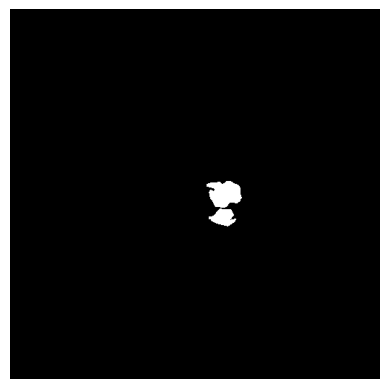

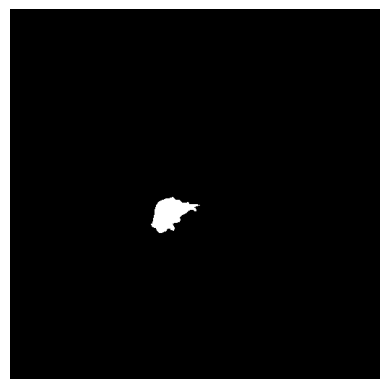

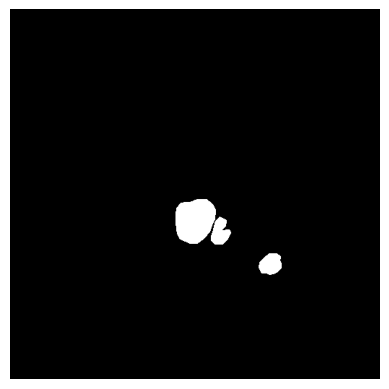

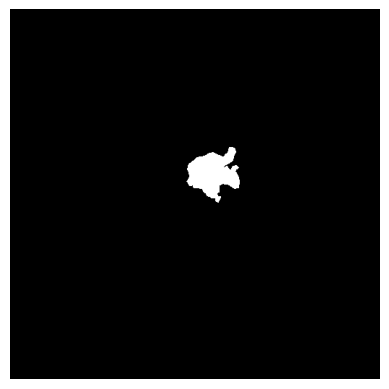

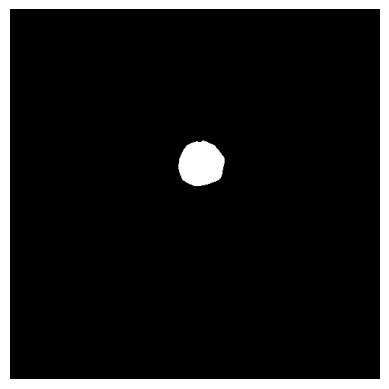

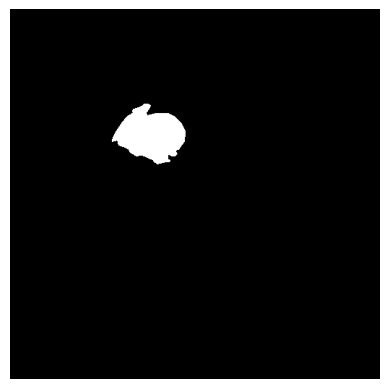

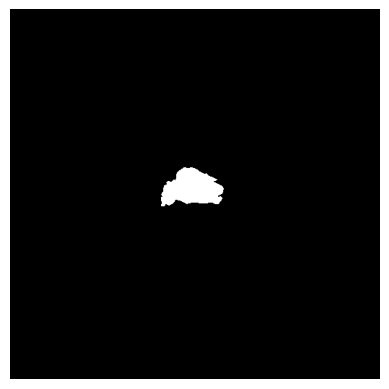

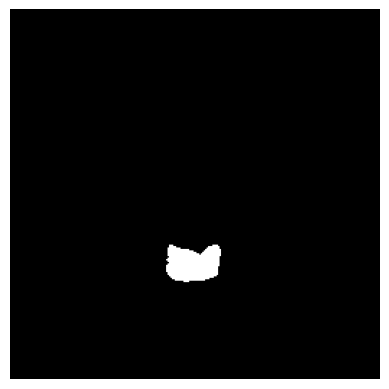

In [23]:
# Get one batch
for i in range(BATCH_SIZE):
    image, mask = train_loader.dataset[i][0].cpu(), train_loader.dataset[i][1].cpu()
    plt.imshow(mask[0].numpy(), cmap='gray')
    plt.axis('off')
    plt.show()

# Utilities function 

In [24]:
import torch
import torch.nn.functional as F
from torchmetrics.segmentation import DiceScore
from torchmetrics.classification import BinaryJaccardIndex
def dice_loss(probs, targets, threshold=0.5):
    """
    prob: Predicted tensor (batch_size, H, W, 2) for 2 classes (tumor and background)
    targets: Ground truth tensor (batch_size, H, W, 1) for binary mask (tumor=1, background=0)
    """
    # Convert prob to one-hot encoding
    # Note that first channel in probs is for background, second channel is for tumor
    # So we take the second channel for tumor prediction
    probs = probs[..., 1].unsqueeze(-1)  # (batch_size, H, W, 1)
    preds = torch.where(probs >= threshold, 1, 0).int()
    targets = targets.int()
    # Calculate Dice Score
    dice = DiceScore(num_classes=2, input_format='one-hot')(preds, targets)
    return 1 - dice

def binary_cross_entropy_loss(probs, targets):
    return F.binary_cross_entropy(probs[..., 1].unsqueeze(-1), targets)

def total_loss(probs, targets, smooth=1e-6):
    dice = dice_loss(probs, targets, smooth)
    bce = binary_cross_entropy_loss(probs, targets)
    return dice + bce

def pixel_accuracy(probs, targets, threshold=0.5):
    preds = (probs[..., 1].unsqueeze(-1) > threshold).float()
    correct = (preds == targets).float()
    accuracy = correct.sum() / correct.numel()
    return accuracy

def jaccard_index(probs, targets, threshold=0.5, smooth=1e-6):
    preds = (probs[..., 1].unsqueeze(-1) > threshold).int()
    targets = targets.int()
    jaccard = BinaryJaccardIndex()(preds, targets)
    return jaccard
    
    
def sensitivity(probs, targets, threshold=0.5, smooth=1e-6):
    # Also known as Recall or True Positive Rate
    # Sensitivity = True Positives / (True Positives + False Negatives)
    # True Positives: preds=1, targets=1
    # False Negatives: preds=0, targets=1
    preds = (probs[..., 1].unsqueeze(-1) > threshold).float()
    targets = targets.float()
    
    true_positives = (preds * targets).sum()
    possible_positives = targets.sum()
    
    sens = (true_positives + smooth) / (possible_positives + smooth)
    return sens

def specificity(probs, targets, threshold=0.5, smooth=1e-6):
    # Also known as True Negative Rate
    # Specificity = True Negatives / (True Negatives + False Positives)
    # True Negatives: preds=0, targets=0
    # False Positives: preds=1, targets=0
    preds = (probs[..., 1].unsqueeze(-1) > threshold).float()
    targets = targets.float()
    
    true_negatives = ((1 - preds) * (1 - targets)).sum()
    possible_negatives = (1 - targets).sum()
    
    spec = (true_negatives + smooth) / (possible_negatives + smooth)
    return spec

def evaluate(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    total_samples = 0

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            preds = model(images)
            loss = total_loss(preds, masks).item()

            total_loss += loss * images.size(0)
            total_samples += images.size(0)

    avg_loss = total_loss / total_samples

    return avg_loss

# Build model

## Basic CNN

## U-net

## SWIN-HAFNet

### Constants

In [25]:
EMBEDDING_DIM = 96
DEPTHS = [2, 2, 2]
NUM_HEADS = [3, 6, 12]
WINDOW_SIZE = 7
MLP_RATIO = 4.0
QKV_BIAS = True
DROP_RATE = 0.0
ATTN_DROP_RATE = 0.0
DROP_PATH_RATE = 0.1
PATCH_SIZE = 4
INPUT_SIZE = 512
CHANNELS = 3
SCALE_FACTOR = 2
SHIFT_SIZE = WINDOW_SIZE // 2
NUM_CLASSES = 2
TOKEN_EMBEDDING_DIM = 512

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.ops.deform_conv import deform_conv2d
from timm.models.swin_transformer import SwinTransformerBlock
from typing import Tuple, Optional


#-------------------Encoder Blocks-------------------#  
class PatchPartition(nn.Module):
    """
    Input shape: (B, H , W, C)
    Output shape: (B, H/patch_size, W/patch_size, C*patch_size*patch_size)
    E.g. 4x downsampling if patch_size=4
    """
    def __init__(self, patch_size=4):
        super(PatchPartition, self).__init__()
        self.patch_size = patch_size
    
    def forward(self, x):
        """
        x: (B,H,W,C)
        """
        B, H, W, C = x.shape
        assert H % self.patch_size == 0 and W % self.patch_size == 0, "H and W must be divisible by patch_size."

        x = x.view(B, H // self.patch_size, self.patch_size, W // self.patch_size, self.patch_size, C)
        x = x.permute(0, 1, 3, 2, 4, 5).contiguous()  # (B, H/ps, W/ps, ps, ps, C)
        x = x.view(B, H // self.patch_size, W // self.patch_size, -1)  # (B, H/ps, W/ps, C*ps*ps)
        return x

class LinearEmbed(nn.Module):
    """
    Linear Embedding layer that flattens the patch partition to a linear embedding.
    Input shape: (B, H/patch_size, W/patch_size, C * patch_size * patch_size)
    Output shape: (B, H/patch_size, W/patch_size, embed_dim)
    """
    def __init__(self, in_channels=CHANNELS * PATCH_SIZE * PATCH_SIZE, embed_dim=EMBEDDING_DIM, norm_layer=nn.LayerNorm):
        super().__init__()
        self.proj = nn.Linear(in_channels, embed_dim)
        self.norm = norm_layer(embed_dim) if norm_layer is not None else nn.Identity()
        
    def forward(self, x):
        """
        Args:
            x: Input tensor of shape (B, H, W, C * patch_size * patch_size)
        Returns:
            x: Embedded tensor of shape (B, H, W, embed_dim)
        """
        x = self.proj(x)  # (B, H, W, embed_dim)
        x = self.norm(x)  # (B, H, W, embed_dim)
        return x

# Swin Transformer Block is imported from timm, so no need to redefine it here.

class PatchMerging(nn.Module):
    """
    Patch Merging Layer that downsamples the input feature map.
    Input shape: (B, H, W, C)
    Output shape: (B, H/2, W/2, 2*C)
    """
    def __init__(self, dim):
        super(PatchMerging, self).__init__()
        self.dim = dim
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)
        self.norm = nn.LayerNorm(4 * dim)
    
    def forward(self, x):
        """
        x: (B, H, W, C)
        """
        B, H, W, C = x.shape
        assert H % 2 == 0 and W % 2 == 0, "H and W must be even."

        x0 = x[:, 0::2, 0::2, :]  # (B, H/2, W/2, C)
        x1 = x[:, 1::2, 0::2, :]  # (B, H/2, W/2, C)
        x2 = x[:, 0::2, 1::2, :]  # (B, H/2, W/2, C)
        x3 = x[:, 1::2, 1::2, :]  # (B, H/2, W/2, C)
        
        x = torch.cat([x0, x1, x2, x3], dim=-1)  # (B, H/2, W/2, 4*C) 
        x = self.norm(x) # (B, H/2, W/2, 4*C)
        x = self.reduction(x) # (B, H/2, W/2, 2*C)
        return x

class Encoder(nn.Module):
    """
    Encoder pathway
    Input shape: (B, H, W, 3)
    Output shape: (B, H/32, W/32, 384) if input_size=512 and patch_size=4
    Also outputs three intermediate features for skip connections:
    to_haf_1: (B, H/4, W/4, 96)
    to_haf_2: (B, H/8, W/8, 192)
    to_haf_3: (B, H/16, W/16, 384)

    Workflow of encoder:
    (B, H, W, 3) - Patch partition-> (B, H/4, W/4, 48) - Linear embed -> (B, H/4, W/4, 96)
        -> Swin blocks (x2) -> (B, H/4, W/4, 96) -> to_haf_1
        -> Patch Merging -> (B, H/8, W/8, 192)
        -> Swin blocks (x2) -> (B, H/8, W/8, 192) -> to_haf_2
        -> Patch Merging -> (B, H/16, W/16, 384)
        -> Swin blocks (x2) -> (B, H/16, W/16, 384) -> to_haf_3
        -> Patch Merging -> (B, H/32, W/32, 768)
        -> Swin blocks (x2) -> (B, H/32, W/32, 768)

    Finally, flatten the spatial dimensions for next stage. 
    Result shape: (B, H/32*W/32, 768)
    -> 32x downsampling if input_size=512 and patch_size=4
    """
    def __init__(self, in_channels=CHANNELS, embed_dim=EMBEDDING_DIM, depths=DEPTHS, num_heads=NUM_HEADS, patch_size=PATCH_SIZE, input_size=INPUT_SIZE):
        super(Encoder, self).__init__()
        self.patch_partition = PatchPartition(patch_size=patch_size)
        self.linear_embed = LinearEmbed(in_channels * patch_size * patch_size, embed_dim)
        # There are 3 variables to hold the outputs for skip connections (will go to HAF blocks after each stage)
        self.to_haf_1 = None
        self.to_haf_2 = None
        self.to_haf_3 = None
        # Calculate resolution after patch partition
        current_resolution = input_size // patch_size  # 512 // 4 = 128
        self.layers = nn.ModuleList()
        
        for i in range(len(depths)):
            layer = nn.ModuleList()
            for j in range(depths[i]):
                block = SwinTransformerBlock(
                    dim=embed_dim * (2 ** i),
                    input_resolution=(current_resolution, current_resolution),  # Use actual resolution
                    num_heads=num_heads[i],
                    window_size=WINDOW_SIZE,
                    shift_size=0 if (j % 2 == 0) else WINDOW_SIZE // 2,
                    mlp_ratio=MLP_RATIO,
                    qkv_bias=QKV_BIAS,
                    attn_drop=ATTN_DROP_RATE,
                    drop_path=DROP_PATH_RATE,
                    norm_layer=nn.LayerNorm
                )
                layer.append(block)
            self.layers.append(layer)
            
            self.layers.append(PatchMerging(embed_dim * (2 ** i)))
            current_resolution = current_resolution // 2  # Resolution halves after patch merging
    
    def forward(self, x):
        # Assume that patch_size == 4
        x = self.patch_partition(x)  # (B, C * 4 * 4, H/4, W/4)
        x = self.linear_embed(x)  # (B, H/4, W/4, embed_dim)
    
        for layer in self.layers:
            if isinstance(layer, nn.ModuleList):
                # Process Swin Transformer blocks
                for block in layer:
                    B, H, W, C = x.shape
                    x = block(x)
                if C == EMBEDDING_DIM:
                    self.to_haf_1 = x
                elif C == EMBEDDING_DIM * 2:
                    self.to_haf_2 = x
                elif C == EMBEDDING_DIM * 4:
                    self.to_haf_3 = x
                    
            else:
                # Process PatchMerging layer (expects (B, H, W, C))
                x = layer(x)
    
        # Flatten spatial dimensions (B, H/32*W/32, 768)
        x = x.view(x.shape[0], -1, x.shape[-1])  
        return x


#-------------------Skip Connection Blocks-------------------#
class HAF(nn.Module):
    """
    Hierarchical Attention Fusion (HAF) Block
    Input shape: x_decoder: (B, H, W, C);
                x_skip: (B, H, W, C)
    Output shape: (B, H, W, C)
    x_decoder -> swin transformer block
                    |
    x_skip ------> cat --> (B, H, W, 2C) --> conv 1x1 -> result
    """
    def __init__(self, dim, input_resolution : Tuple[int, int], num_heads=NUM_HEADS, embedding_dim=EMBEDDING_DIM):
        # dim is C in the docstring
        # resolution is (H, W)
        super(HAF, self).__init__()
        self.swin_block = None
        for i in range(2):
            self.swin_block = SwinTransformerBlock(
                dim=dim,
                input_resolution=input_resolution,
                num_heads=num_heads[0] if dim == embedding_dim else num_heads[1] if dim == embedding_dim * SCALE_FACTOR else num_heads[2],
                window_size=WINDOW_SIZE,
                shift_size=0 if (i % 2 == 0) else WINDOW_SIZE // 2,
                mlp_ratio=MLP_RATIO,
                qkv_bias=QKV_BIAS,
                attn_drop=ATTN_DROP_RATE,
                drop_path=DROP_PATH_RATE,
                norm_layer=nn.LayerNorm
            )
        self.conv1x1 = nn.Conv2d(2 * dim, dim, kernel_size=1)
    
    def forward(self, x_decoder, x_skip):
        x = self.swin_block(x_decoder)  # (B, H, W, C)
        x = torch.cat([x, x_skip], dim=-1)  # (B, H, W, 2C)
        x = x.permute(0, 3, 1, 2).contiguous()  # (B, 2C, H, W)
        x = self.conv1x1(x)  # (B, C, H, W)
        x = x.permute(0, 2, 3, 1).contiguous()  # (B, H, W, C)
        return x


#-------------------Decoder Blocks-------------------#

   
class PatchExpanding(nn.Module):
    """
    Patch Expanding Layer that upsamples the input feature map.
    Input shape: (B, H, W, C)
    Output shape: (B, 2*H, 2*W, C/2)
    """
    def __init__(self, dim, dim_scale=SCALE_FACTOR):
        super(PatchExpanding, self).__init__()
        self.dim = dim
        self.expand = nn.Linear(dim, 2 * dim, bias=False)
        self.norm = nn.LayerNorm(dim // dim_scale)

    def forward(self, x):
        """
        x: (B, H, W, C)
        """
        B, H, W, C = x.shape
        x = self.expand(x)  # (B, H, W, 2*C)
        x = x.view(B, H, W, 2, 2, C // 2)  # (B, H, W, 2, 2, C/2)
        x = x.permute(0, 1, 3, 2, 4, 5).contiguous()  # (B, H, 2, W, 2, C/2)
        x = x.view(B, H * 2, W * 2, C // 2)  # (B, 2*H, 2*W, C/2)
        x = self.norm(x)  # (B, 2*H, 2*W, C/2)
        return x
    
class ACA(nn.Module):
    """
    Adaptive Contextual Aggregator (ACA) Block
    Input shape: (B, H, W, C)
    Output shape: (B, H, W, C)
    
    Workflow:
            --> Swin Transformer Block      |
            |               
    (B, H, W, C) ->                      -->cat (B, H, W, 3C) --> conv 1 x 1 -> (B, H, W, C)    
            | --> DeformableConv2d          |
            
    """
    def __init__(self, dim, input_resolution : Tuple[int, int], depth=2, num_heads=NUM_HEADS, embedding_dim=EMBEDDING_DIM):
        super(ACA, self).__init__()
        self.swin_layers = nn.ModuleList()
        for i in range(depth):
            swin_block = SwinTransformerBlock(
                dim=dim,
                input_resolution=input_resolution,
                num_heads=num_heads[0] if dim == embedding_dim else num_heads[1] if dim == embedding_dim * SCALE_FACTOR else num_heads[2],
                window_size=WINDOW_SIZE,
                shift_size=0 if (i % 2 == 0) else WINDOW_SIZE // 2,
                mlp_ratio=MLP_RATIO,
                qkv_bias=QKV_BIAS,
                attn_drop=ATTN_DROP_RATE,
                drop_path=DROP_PATH_RATE,
                norm_layer=nn.LayerNorm
            )
            self.swin_layers.append(swin_block)
        self.conv1x1 = nn.Conv2d(3 * dim, dim, kernel_size=1)
    
    def forward(self, x_decoder, deform_group=1, deform_kernel_size=3):
        B, H , W, C = x_decoder.shape
        for layer in self.swin_layers:
            x_swin = layer(x_decoder)  # (B, H, W, C)
        x_deform = deform_conv2d(input=x_decoder.permute(0, 3, 1, 2), # (B, C, H, W)
                                 offset=torch.zeros(B, 2*deform_group*deform_kernel_size*deform_kernel_size, H, W, device=x_decoder.device),
                                 weight=torch.ones(C, C // deform_group , deform_kernel_size, deform_kernel_size, device=x_decoder.device) / (deform_kernel_size*deform_kernel_size),
                                 padding=(deform_kernel_size//2, deform_kernel_size//2),)
        x_deform = x_deform.permute(0, 2, 3, 1)  # (B, H, W, C)
        x = torch.cat([x_decoder, x_swin, x_deform], dim=-1)  # (B, H, W, 3C)
        x = x.permute(0, 3, 1, 2).contiguous()  # (B, 3C, H, W)
        x = self.conv1x1(x)  # (B, C, H, W)
        x = x.permute(0, 2, 3, 1).contiguous()  # (B, H, W, C)
        return x


class Decoder (nn.Module):
    """
    Decoder pathway
    Input shape: (B, H/32*W/32, 768) if input_size=512 and patch_size=4
    Output shape: (B, H/2, W/2, 48) if input_size=512 and patch_size=4
    """
    def __init__(self, in_channels=SCALE_FACTOR**(len(DEPTHS))*EMBEDDING_DIM, depths=DEPTHS, input_size=INPUT_SIZE, patch_size=PATCH_SIZE, embedding_dim=EMBEDDING_DIM):
        """
        in_channels: channels of the input feature map (from encoder) 
        """
        super(Decoder, self).__init__()
        self.layers = nn.ModuleList()
        self.to_haf_1 = None
        self.to_haf_2 = None
        self.to_haf_3 = None
        self.haf_1 = HAF(dim=embedding_dim,
                            input_resolution=(input_size // (patch_size), input_size // (patch_size)),
                            embedding_dim=embedding_dim)
        self.haf_2 = HAF(dim=embedding_dim * SCALE_FACTOR,
                            input_resolution=(input_size // (patch_size * SCALE_FACTOR), input_size // (patch_size * SCALE_FACTOR)),
                            embedding_dim=embedding_dim)
        self.haf_3 = HAF(dim=embedding_dim * SCALE_FACTOR**2,
                            input_resolution=(input_size // (patch_size * SCALE_FACTOR**2), input_size // (patch_size * SCALE_FACTOR**2)),
                            embedding_dim=embedding_dim)
        current_resolution =  input_size // (patch_size * (SCALE_FACTOR ** len(DEPTHS)))  # Starting resolution
        for depth in depths:
            self.layers.append(PatchExpanding(in_channels))
            in_channels //= 2  # Halve the channels after each upsampling
            current_resolution *= 2  # Double the resolution after each upsampling
            
            layer = nn.ModuleList()
            layer.append(ACA(in_channels, input_resolution=(current_resolution, current_resolution)))
            self.layers.append(layer)
        
        self.layers.append(PatchExpanding(in_channels))
        in_channels //= 2  # Final halving of channels
        current_resolution *= 2  # Final doubling of resolution

    def forward(self, x, x_encode_haf_1, x_encode_haf_2, x_encode_haf_3):
        # x: (B, H/32*W/32, 768) if input_size=512, patch_size=4 and DEPTHS=[2,2,2]
        B, _, C = x.shape
        x = x.view(B, int((INPUT_SIZE // (PATCH_SIZE * (SCALE_FACTOR ** len(DEPTHS))))), int((INPUT_SIZE // (PATCH_SIZE * (SCALE_FACTOR ** len(DEPTHS))))), C)  # (B, H/32, W/32, 768)
        for layer in self.layers:
            if isinstance(layer, nn.ModuleList):
                # Process ACA blocks
                for block in layer:
                    B, H, W, C = x.shape
                    x = block(x)  # (B, H, W, C)
                if C == EMBEDDING_DIM * (SCALE_FACTOR ** 2):
                    self.to_haf_3 = self.haf_3(x, x_encode_haf_3)  # (B, H, W, 384)
                elif C == EMBEDDING_DIM * SCALE_FACTOR:
                    self.to_haf_2 = self.haf_2(x, x_encode_haf_2)  # (B, H, W, 192)
                elif C == EMBEDDING_DIM:
                    self.to_haf_1 = self.haf_1(x, x_encode_haf_1)  # (B, H, W, 96)

            else: # PatchExpanding layer
                if C == EMBEDDING_DIM * (SCALE_FACTOR ** 2):
                    x += self.to_haf_3
                elif C == EMBEDDING_DIM * SCALE_FACTOR:
                    x += self.to_haf_2
                elif C == EMBEDDING_DIM:
                    x += self.to_haf_1
                x = layer(x)  # (B, 2*H, 2*W, C/2)
        return x  # (B, H/2, W/2, 48)
    

#-------------------Contextual Bottleneck Enhancer (CBE) Blocks-------------------#

class CBE(nn.Module):
    """
    Contextual Bottleneck Enhancer (CBE) Block
    Input shape: (B, H * W, C)
    Output shape: (B, H * W, C)
    Workflow:
    x --> Shifted along width axis followed by linear projection
        --> Shifted MLP layer (across width axis) --> depthwise conv 3x3 --> Gelu activation
        --> Shifted along width axis followed by linear projection
        --> Normalized (called x_shifted_w)
    Residual connection: x + x_shifted_w
    """
    def __init__(self, in_channels=SCALE_FACTOR**(len(DEPTHS))*EMBEDDING_DIM, token_embedding_dim=TOKEN_EMBEDDING_DIM):
        super(CBE, self).__init__()
        self.shifted_proj1 = nn.Linear(in_channels, token_embedding_dim) 
        self.shifted_mlp1 = nn.Sequential(
            nn.Linear(token_embedding_dim, token_embedding_dim * 2),
            nn.ReLU(inplace=True),
            nn.Linear(token_embedding_dim * 2, token_embedding_dim)
        )
        self.depthwise_conv = nn.Conv2d(token_embedding_dim, token_embedding_dim, kernel_size=3, padding=1, groups=token_embedding_dim)
        self.gelu = nn.GELU()
        self.shifted_proj2 = nn.Linear(token_embedding_dim, token_embedding_dim)
        self.shifted_mlp2 = nn.Sequential(
            nn.Linear(token_embedding_dim, token_embedding_dim * 2),
            nn.ReLU(inplace=True),
            nn.Linear(token_embedding_dim * 2, token_embedding_dim)
        )
        self.norm = nn.LayerNorm(token_embedding_dim)
        self.feature_proj = nn.Linear(token_embedding_dim, in_channels)
    def shift_along_width(self, x, shift_size=SHIFT_SIZE):
        """
        Shift the feature map along the width axis.
        x: (B, H, W, C)
        """
        B, HW, C = x.shape
        H = W = int(HW ** 0.5)  # Assuming square input for simplicity
        x = x.view(B, H, W, C)
        x = torch.roll(x, shifts=shift_size, dims=2)  # Shift along width axis
        x = x.view(B, HW, C)
        return x

    def forward(self, x):
        # x: (B, H * W, C)
        x_shifted = self.shift_along_width(x)  # (B, H*W, C)
        x_shifted = self.shifted_proj1(x_shifted)  # (B, H*W, token_embedding_dim)
        x_shifted = self.shifted_mlp1(x_shifted)  # (B, H*W, token_embedding_dim)
        
        B, HW, C = x_shifted.shape
        H = W = int(HW ** 0.5)  # Assuming square input
        
        x_shifted = x_shifted.view(B, H, W, C).permute(0, 3, 1, 2).contiguous()  # (B, token_embedding_dim, H, W)
        x_shifted = self.depthwise_conv(x_shifted)  # (B, token_embedding_dim, H, W)
        x_shifted = self.gelu(x_shifted)  # (B, token_embedding_dim, H, W)
        x_shifted = x_shifted.permute(0, 2, 3, 1).contiguous().view(B, HW, C)  # (B, H*W, token_embedding_dim)
        
        x_shifted = self.shift_along_width(x_shifted, shift_size=-SHIFT_SIZE)  # (B, H*W, token_embedding_dim)
        x_shifted = self.shifted_proj2(x_shifted)  # (B, H*W, token_embedding_dim)
        x_shifted = self.shifted_mlp2(x_shifted)  # (B, H*W, token_embedding_dim)
        
        x_shifted = self.norm(x_shifted)  # (B, H*W, token_embedding_dim)
        x_shifted = self.feature_proj(x_shifted)  # (B, H*W, C)
        
        x = x + x_shifted 
        return x  # (B, H*W, C)

#-------------------Swin-HAFNet-------------------#
class SwinHAFNet(nn.Module):
    """
    Swin-HAFNet model
    Input shape: (B, H, W, 3)
    Output shape: (B, H, W, NUM_CLASSES)
    """
    def __init__(self, in_channels=CHANNELS, embed_dim=EMBEDDING_DIM, depths=DEPTHS, num_heads=NUM_HEADS, patch_size=PATCH_SIZE, input_size=INPUT_SIZE, num_classes=NUM_CLASSES):
        super(SwinHAFNet, self).__init__()
        self.encoder = Encoder(in_channels=in_channels, 
                               embed_dim=embed_dim, 
                               depths=depths, 
                               num_heads=num_heads, 
                               patch_size=patch_size, 
                               input_size=input_size)
        self.cbe = CBE(in_channels=SCALE_FACTOR**(len(depths))*embed_dim)
        self.decoder = Decoder(in_channels=SCALE_FACTOR**(len(depths))*embed_dim, 
                               depths=depths, 
                               input_size=input_size, 
                               patch_size=patch_size, 
                               embedding_dim=embed_dim)
        self.linear_projection = nn.Linear(embed_dim // 2, num_classes)
        # Interpolation layer to upsample the output to original size
        # self.final_upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        # Learnable upsampling layer
        self.final_upsample = nn.ConvTranspose2d(num_classes, num_classes, kernel_size=4, stride=2, padding=1)
    def forward(self, x):
        x = self.encoder(x)  # (B, H/32*W/32, 768)
        x = self.cbe(x)  # (B, H/32*W/32, 768)
        x = self.decoder(x, self.encoder.to_haf_1, self.encoder.to_haf_2, self.encoder.to_haf_3)  # (B, H/2, W/2, 48)
        x = self.linear_projection(x)  # (B, H/2, W/2, num_classes)
        x = x.permute(0, 3, 1, 2).contiguous()  # (B, num_classes, H/2, W/2)
        x = self.final_upsample(x)  # (B, num_classes, H, W)
        x = x.permute(0, 2, 3, 1).contiguous()  # (B, H, W, num_classes)
        return x

# U-net

# Training

In [ ]:
from transformers import Trainer, TrainingArguments

EPOCHS = 50
LEARNING_RATE = 1e-4
BATCH_SIZE = 8
WARMUP_STEPS = 500
WEIGHT_DECAY = 0.01
LOGGING_STEPS = 10
LOGGING_DIR = './logs'
import os
os.makedirs(LOGGING_DIR, exist_ok=True)

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs : DataLoader, return_outputs=False):
        images = inputs[0]
        masks = inputs[1]
        outputs = model(images)
        loss = total_loss(outputs, masks)
        return (loss, outputs) if return_outputs else loss
    

train_args = TrainingArguments(
    output_dir="./swin_hafnet_output",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,
    weight_decay=WEIGHT_DECAY,
    logging_dir=LOGGING_DIR,
    logging_steps=LOGGING_STEPS,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    jaccard = jaccard_index(torch.tensor(predictions), torch.tensor(labels))
    pixel_acc = pixel_accuracy(torch.tensor(predictions), torch.tensor(labels))
    return {
        "jaccard": jaccard,
        "pixel_accuracy": pixel_acc
    }

model = SwinHAFNet().to(DEVICE)
trainer = CustomTrainer(
    model=model,
    args=train_args,
    train_dataset=train_loader.dataset,
    eval_dataset=val_loader.dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

eval_result = trainer.evaluate(eval_dataset=test_loader.dataset)
print(f"Test set evaluation results: {eval_result}")

2025-10-02 03:29:06.798607: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759375747.117988      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759375747.211574      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>